In [ ]:
## 모델 불러오기

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import tensorflow as tf

# 시드 고정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 1. Sonar데이터 셋 불러오기
df = pd.read_csv('sonar.csv', header=None)
dataset = df.values

# 2. 입력 X, 정답 y 분리
X = dataset[:, : 60].astype(float)
Y_obj = dataset[:, 60]

# 3. 문자 -> 숫자 : 원-핫 인코딩
e = LabelEncoder()
e.fit(Y_obj)
y = e.transform(Y_obj)

# 4. train x, test y 분리
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

# 5. 저장된 모델 불러오기
model = load_model('my_model.keras')
print('모델이 성공적으로 로드되었습니다')

# 6. 불러온 모델로 테스트 데이터 평가
loss, accuracy = model.evaluate(x_train, y_train)
print("\n Test Accuracy : %.2f" % accuracy)

# 7. 예측 수행
predictions = model.predict(x_train)
print("\n 예측 결과 예시 :", predictions[:5].flatten())
print("실제 정답 :", y_test[:5])

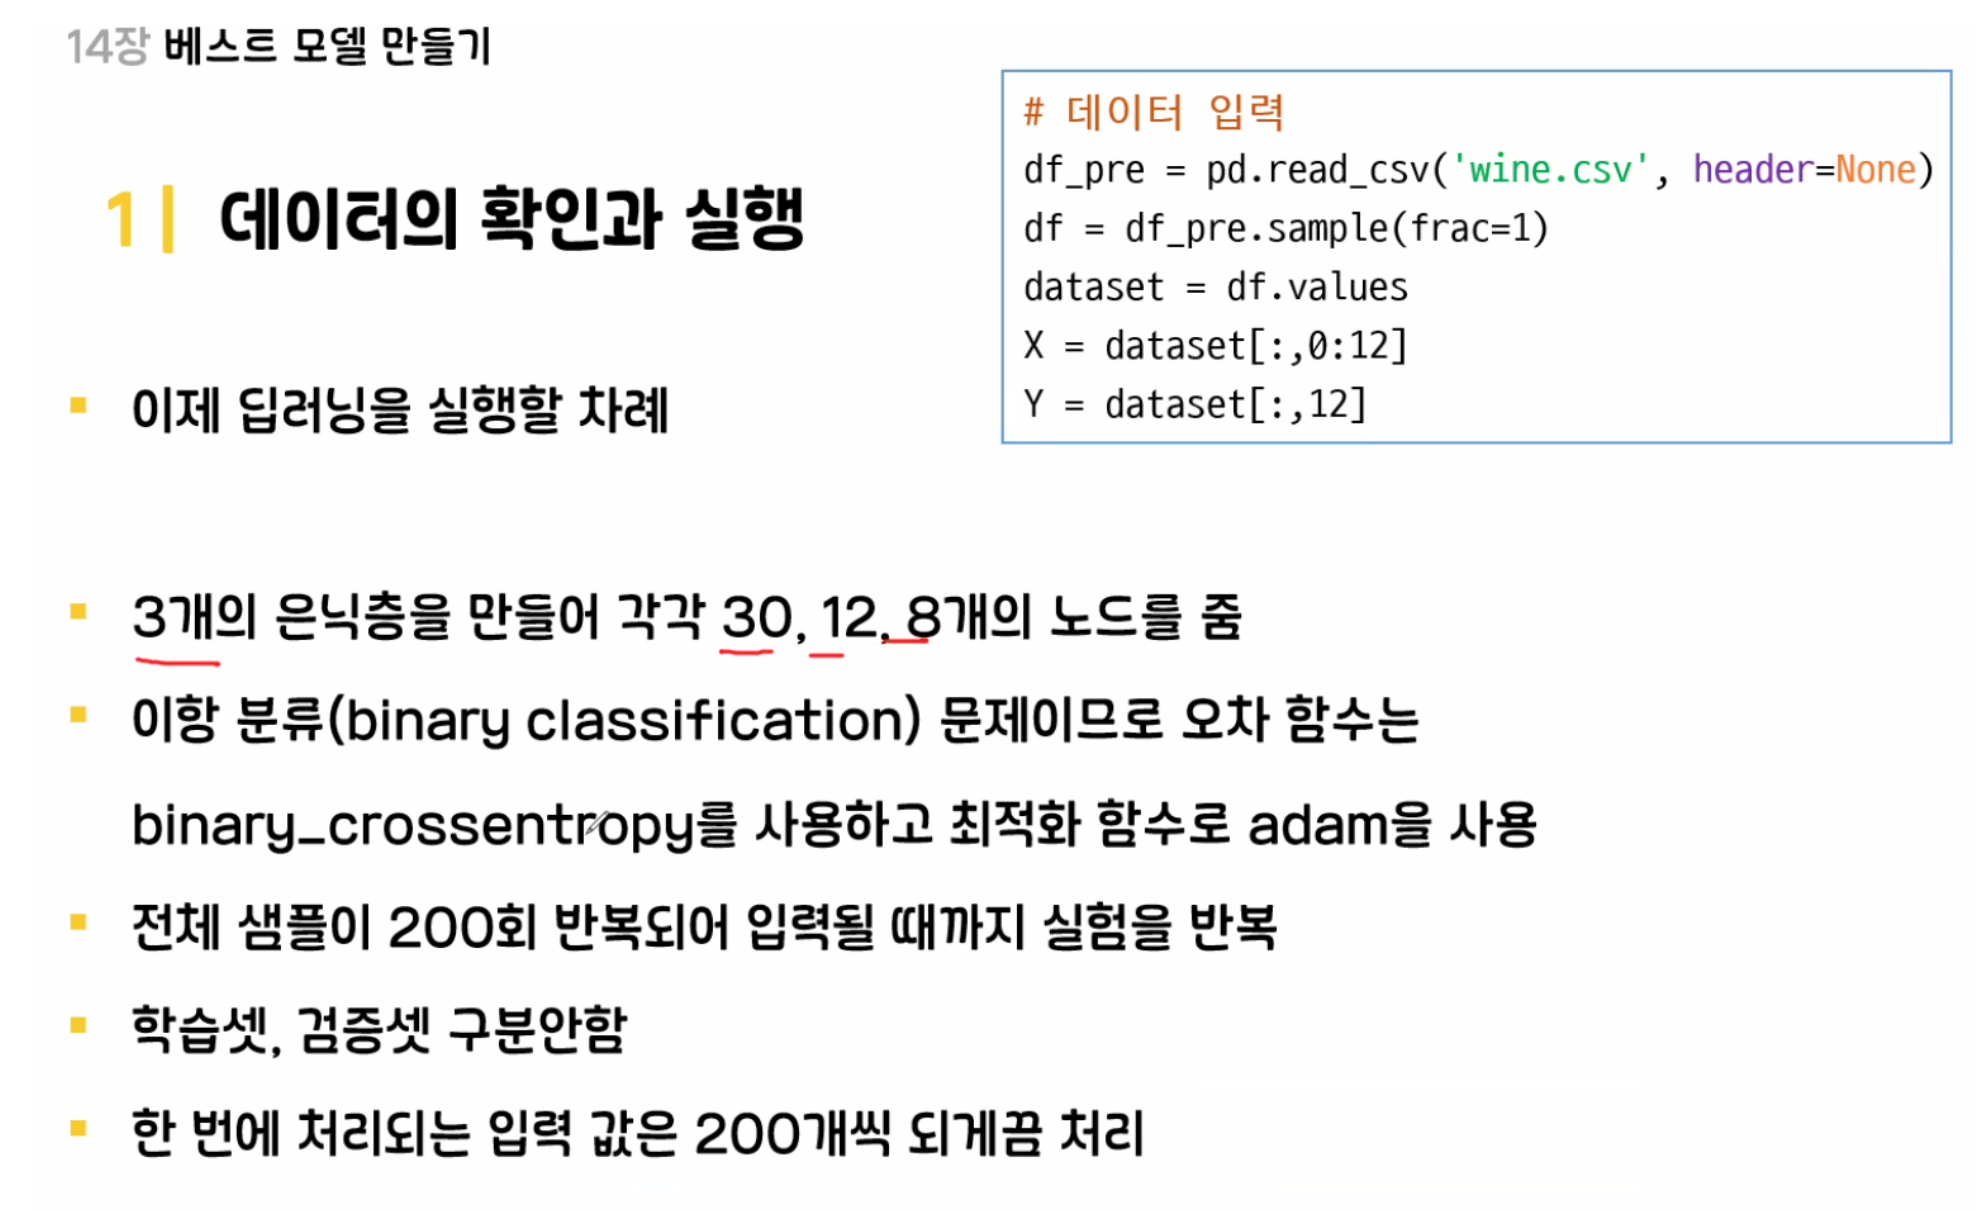

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# seed 값 설정
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

# 6497개
# 0 ~ 12
# 뭐가 속성이고 클래스인지는 잘...
# 11, 12가 클래스면(int64니까)
# 검색해보니 마지막것만 품질점수, 나머지는 속성 .astype(float64)로 int -> float
df_pre = pd.read_csv('wine.csv', header=None)
df = df_pre.sample(frac=1) # 전체 데이터를 100% 추출하면서 무작위로 가져온다.
# print(df.info())
dataset = df.values
X = dataset[:, 0:12].astype(float)
Y = dataset[:, 12]
# 모델 설정
model = Sequential()
model.add(Input(shape=(12,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 실행
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=10, batch_size=200) # epochs = 10은 시간 상...

# 모델 평가
scores = model.evaluate(X, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

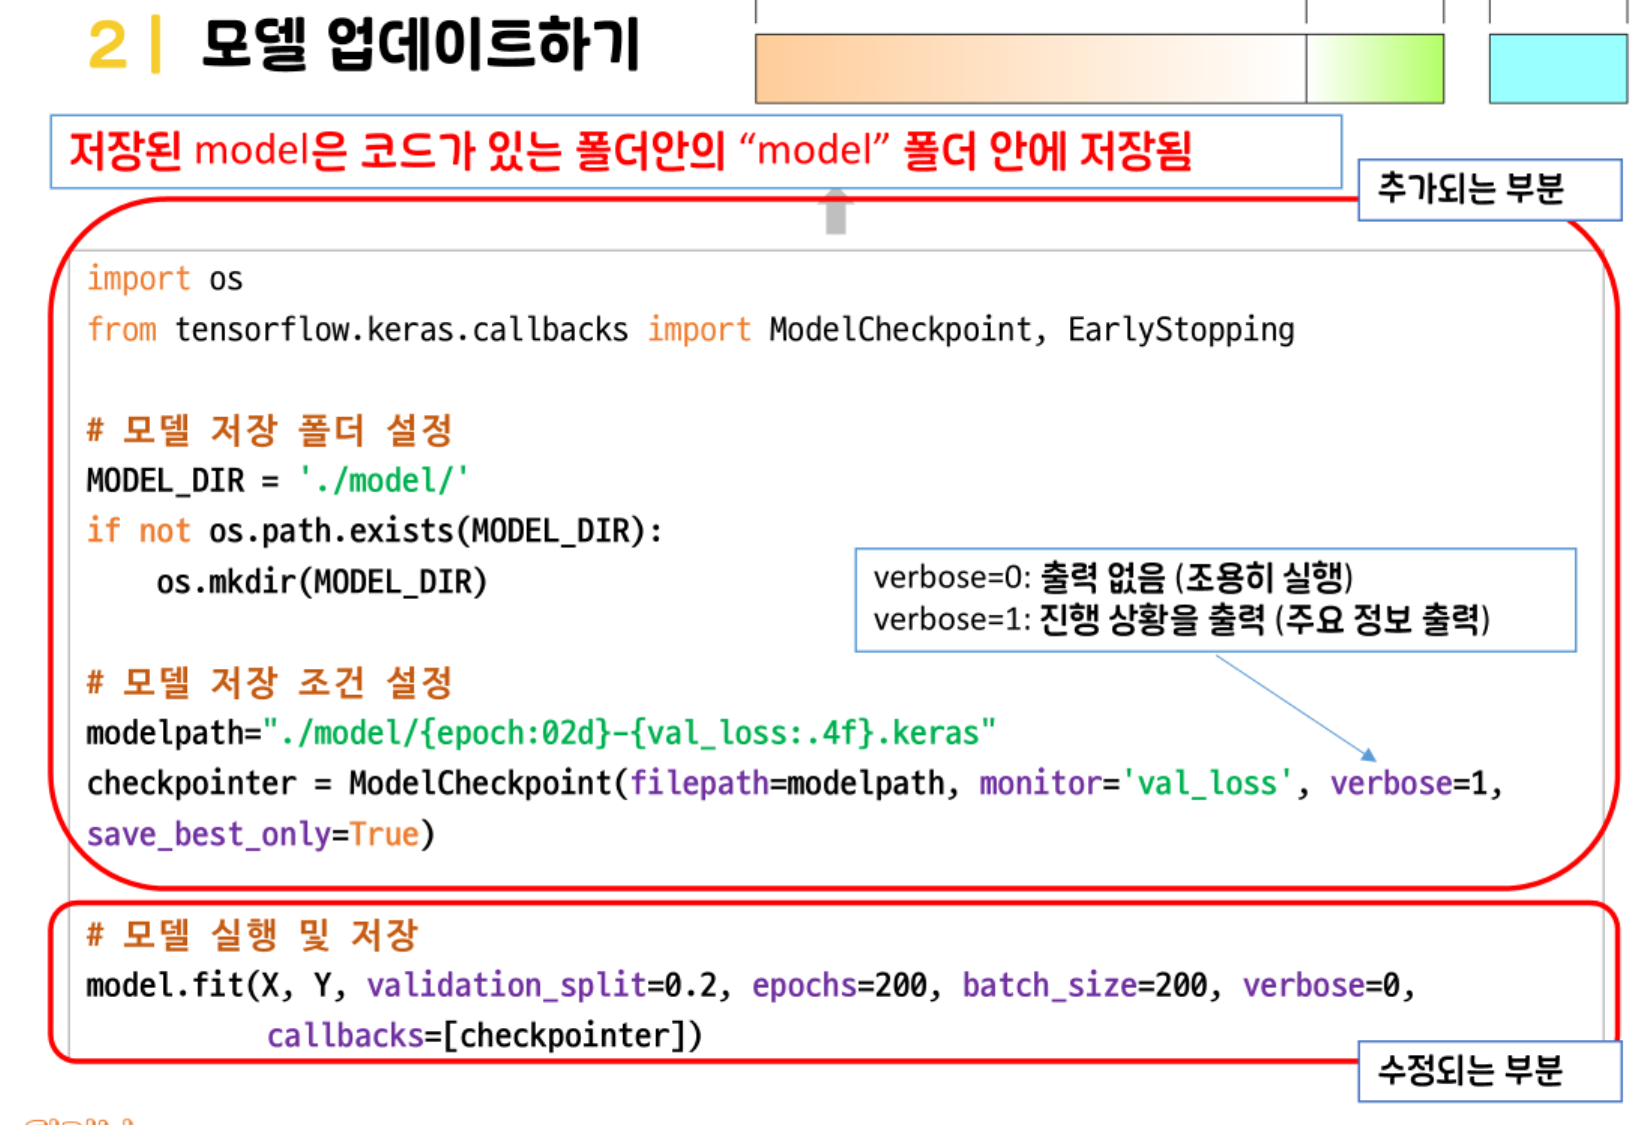

In [ ]:
# 딥러닝 모델 학습 과정 중, 성능이 개선될 때마다 모델 파일을 지정된 폴더에 저장한다.
# modelpath : 저장될 파일명 + 경로
# ModelCheckpoint() : 모델을 저장하는 콜백 함수
# monitor() : 검증 데이터의 '오차'값을 모니터링 기준으로 한다.
# save_best_only = True : 오차 값이 '개선'되었을 때 덮어쓰거나 새로 저장한다.

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, Earylstopping

# 모델 저장 '폴더' 설정
MODEL_DIR = "./model/"

# 폴더가 없다면 생성
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
modelpath = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)

# 모델 실행 및 저장
# callbacks : 에포크가 끝날 때마다, checkpointer 호출
model.fit(X, Y, validation_split=0.2, epochs=200, batch_size=200, verbose=0, callbacks=[checkpointer])

In [ ]:
## 위 코드 추가 ##

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# seed 값 설정
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 생성
df_pre = pd.read_csv('wine.csv', header=None)
df = df_pre.sample(frac=1) # 전체 데이터를 100% 추출하면서 무작위로 가져온다.
# print(df.info())
dataset = df.values
X = dataset[:, 0:12].astype(float)
Y = dataset[:, 12]

# 모델 설정
model = Sequential()
model.add(Input(shape=(12,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 실행
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.fit(X, Y, epochs=10, batch_size=200) # epochs = 10은 시간 상...

MODEL_DIR = "./model/"
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
model_path = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=0, save_best_only=True)

# 모델 실행 및 저장
model.fit(X, Y, validation_split=0.2, epochs=30, batch_size=200, verbose=0, callbacks=[checkpointer])

# 모델 평가
scores = model.evaluate(X, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))